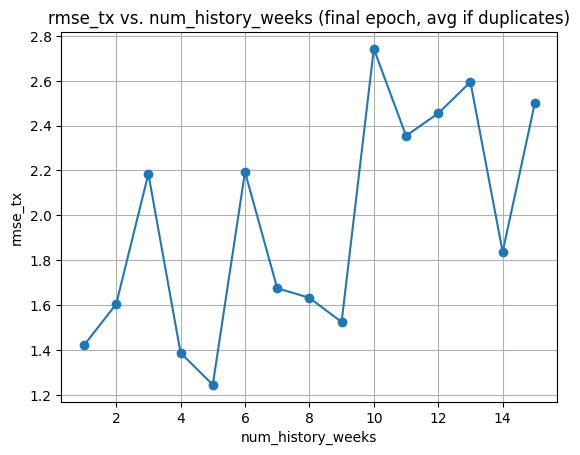

In [6]:
#!/usr/bin/env python
# Show_num_history_weeks_graph.py

import json
import pandas as pd
import matplotlib.pyplot as plt
import math

# 1) 從 log.json 讀取紀錄
with open("log.json", "r") as f:
    logs = json.load(f)

# 2) 轉成 DataFrame 方便操作
df = pd.DataFrame(logs)

# 指定要繪圖的指標 (你可以改成 argparse 或其他方式指定)
metric = "rmse_tx"

# 3) 針對每個 num_history_weeks，找出最大 epoch
#    groupby(...).transform("max") 會在該組所有資料都標上「最大 epoch 值」以方便篩選
max_epoch_for_group = df.groupby("num_history_weeks")["epoch"].transform("max")

# 只保留「epoch 等於該組最大值」的紀錄
df_final_epoch = df[df["epoch"] == max_epoch_for_group].copy()

# 4) 若同一個 num_history_weeks 在最大 epoch 處，出現多筆紀錄，
#    就把這些紀錄的 metric 值取平均
df_agg = (
    df_final_epoch
    .groupby("num_history_weeks", as_index=False)
    .agg({metric: "mean"})  # 這裡可以再加上更多指標同時取平均
)

# 5) 按照 num_history_weeks 進行排序
df_agg = df_agg.sort_values(by="num_history_weeks")

# 6) 取得 x, y 用於繪圖
x = df_agg["num_history_weeks"]
y = df_agg[metric]

# 7) 繪製折線圖
plt.figure()
plt.plot(x, y, marker="o")  # 折線+圓點
plt.xlabel("num_history_weeks")
plt.ylabel(metric)
plt.title(f"{metric} vs. num_history_weeks (final epoch, avg if duplicates)")
plt.grid(True)

# 8) 顯示圖表
plt.show()
